### **Agent**

![simple agent.png](<attachment:simple agent.png>)
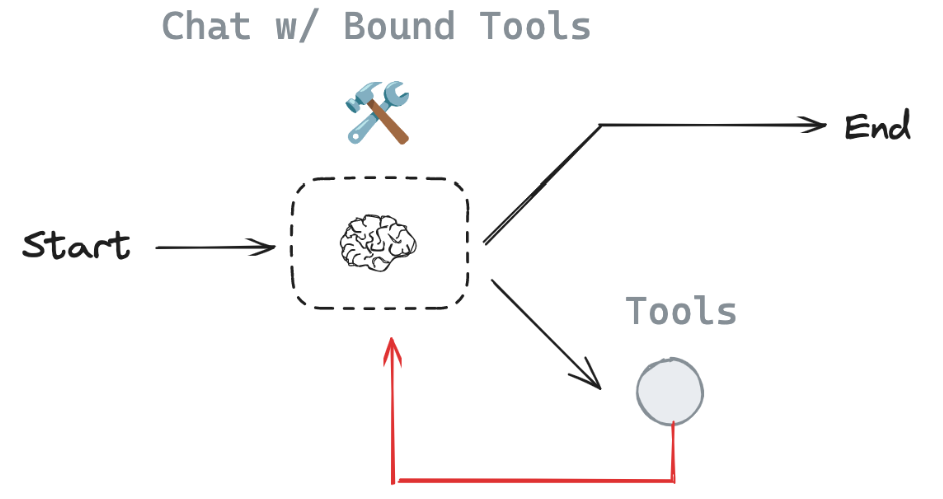

In [ ]:
%%capture --no-stderr
%pip install --quiet -U langchain_openai langchain_core langgraph langgraph-prebuilt

In [4]:
import os, openai
from dotenv import load_dotenv, find_dotenv
from langchain_openai import ChatOpenAI

_ = load_dotenv(find_dotenv())
openai.api_key = os.environ['OPENAI_API_KEY']

llm_model = 'gpt-4o'
chat = ChatOpenAI(model = llm_model)

In [5]:
def multiply(a: int, b: int) -> int:
    """Multiply a and b.

    Args:
        a: first int
        b: second int
    """
    return a * b

def add(a: int, b: int) -> int:
    """Adds a and b.

    Args:
        a: first int
        b: second int
    """
    return a + b

def divide(a: int, b: int) -> float:
    """Divide a and b.

    Args:
        a: first int
        b: second int
    """
    return a / b

tools = [add, multiply, divide]

# For this ipynb we set parallel_tool_calls to false as math generally is done sequentially
llm_with_tools = chat.bind_tools(tools, parallel_tool_calls = False)

In [ ]:
from langgraph.graph import MessagesState
from langchain_core.messages import HumanMessage, SystemMessage
from langgraph.graph import START, StateGraph
from langgraph.prebuilt import tools_condition, ToolNode
from IPython.display import Image, display

# System message
sys_msg = SystemMessage(content = 'You are a helpful assistant tasked with performing arithmetic on a set of inputs.')

# Node
def assistant(state: MessagesState):
   return {'messages': [llm_with_tools.invoke([sys_msg] + state['messages'])]}

# Graph
builder = StateGraph(MessagesState)

# Define nodes: these do the work
builder.add_node('assistant', assistant)
builder.add_node('tools', ToolNode(tools))

# Define edges: these determine how the control flow moves
builder.add_edge(START, 'assistant')
builder.add_conditional_edges(
    'assistant',
    # If the latest message (result) from assistant is a tool call -> tools_condition routes to tools
    # If the latest message (result) from assistant is a not a tool call -> tools_condition routes to END
    tools_condition,
)
builder.add_edge('tools', 'assistant')
react_graph = builder.compile()

# Show
display(Image(react_graph.get_graph(xray = True).draw_mermaid_png()))

In [ ]:
messages = [HumanMessage(content = 'Compute (6+3*8)/5')]
messages = react_graph.invoke({'messages': messages})
for m in messages['messages']:
    m.pretty_print()

# If we add the following code, the model wont know what to *2
# messages = [HumanMessage(content = 'Multiply by 2.')]
# messages = react_graph.invoke({'messages': messages})
#
# But if we modify, the model will know which to *2
# messages = [
#     HumanMessage(content = 'Compute (6+3*8)/5'),
#     HumanMessage(content = 'Multiply by 2.')
# ]

### **Memory**

In [15]:
from langgraph.checkpoint.memory import MemorySaver
memory = MemorySaver()
react_graph_memory = builder.compile(checkpointer = memory)

When using memory, a `thread_id` must be specified to store the sequence of graph states.

At each step, the checkpointer saves the current state to the associated thread, allowing future access to this state history via the `thread_id`.

![agent memory.png](<attachment:agent memory.png>)
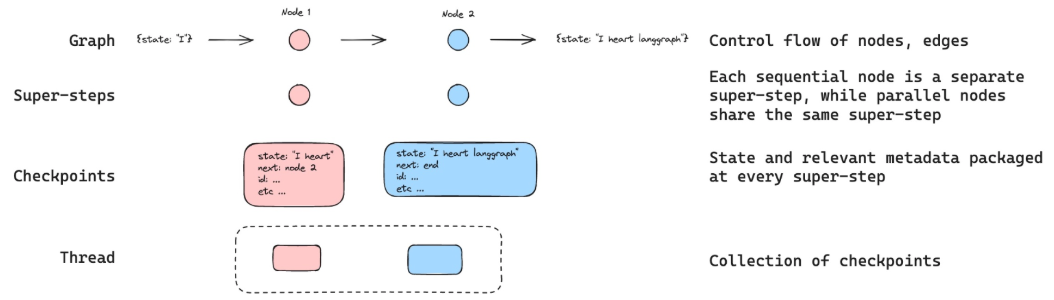

In [ ]:
# Specify a thread
# All states and messages in this session are grouped under thread '1'. Can be any other str
config = {'configurable': {'thread_id': '1'}}

# Specify an input
messages = [HumanMessage(content='Add 3 and 4.')]
messages = react_graph_memory.invoke({'messages': messages}, config)

messages = [HumanMessage(content='Multiply by 2.')]
messages = react_graph_memory.invoke({'messages': messages}, config)

for m in messages['messages']:
    m.pretty_print()